In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import re
from collections import Counter

In [2]:
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
NUM_CLASSES = 2
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 8
MAX_VOCAB_SIZE = 20000
MAX_SEQ_LEN = 200
GRAD_CLIP = 5.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.split()

def build_vocab(texts, max_size):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for idx, (word, _) in enumerate(counter.most_common(max_size-2), start=2):
        vocab[word] = idx
    return vocab

def encode(text, vocab):
    tokens = tokenize(text)
    encoded = [vocab.get(t, vocab["<UNK>"]) for t in tokens][:MAX_SEQ_LEN]
    return torch.tensor(encoded, dtype=torch.long)

In [4]:
train_csv_path = "../data/imdb/train.csv"
test_csv_path = "../data/imdb/test.csv"

print("Carico dataset dai CSV locali...")

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()
test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

print("Train size:", len(train_texts), "Test size:", len(test_texts))

vocab = build_vocab(train_texts, MAX_VOCAB_SIZE)
print("Vocabolario costruito:", len(vocab), "token")

Carico dataset dai CSV locali...
Train size: 25000 Test size: 25000
Vocabolario costruito: 20000 token


In [ ]:
class TextDataset(Dataset):

    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoded = encode(self.texts[idx], self.vocab)
        return encoded, torch.tensor(self.labels[idx], dtype=torch.long)

def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded.to(DEVICE), torch.tensor(labels).to(DEVICE), lengths.to(DEVICE)

In [6]:
train_dataset = TextDataset(train_texts, train_labels, vocab)
test_dataset = TextDataset(test_texts, test_labels, vocab)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
class RNNClassifier(nn.Module):
    
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBEDDING_DIM, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=EMBEDDING_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True,
            bidirectional=True,
            nonlinearity='tanh'
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(HIDDEN_DIM*2, NUM_CLASSES)
    
    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.rnn(packed)
        hidden_cat = torch.cat([hidden[-2], hidden[-1]], dim=1)
        out = self.dropout(hidden_cat)
        logits = self.fc(out)
        return logits

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBEDDING_DIM, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=EMBEDDING_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(HIDDEN_DIM*2, NUM_CLASSES)
    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (hidden, cell) = self.lstm(packed)
        hidden_cat = torch.cat([hidden[-2], hidden[-1]], dim=1)
        out = self.dropout(hidden_cat)
        logits = self.fc(out)
        return logits

In [9]:
criterion = nn.CrossEntropyLoss()

In [10]:
def train_model(model, train_loader, epochs=EPOCHS):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for texts, labels, lengths in train_loader:
            optimizer.zero_grad()
            outputs = model(texts, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")
    return train_losses

In [11]:
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for texts, labels, lengths in data_loader:
            outputs = model(texts, lengths)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    print(f"Test Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels

In [12]:
rnn_model = RNNClassifier(len(vocab)).to(DEVICE)

In [13]:
rnn_train_losses = train_model(rnn_model, train_loader)

Epoch 1/8 - Loss: 0.6951
Epoch 2/8 - Loss: 0.6517
Epoch 3/8 - Loss: 0.6095
Epoch 4/8 - Loss: 0.5463
Epoch 5/8 - Loss: 0.5021
Epoch 6/8 - Loss: 0.4221
Epoch 7/8 - Loss: 0.3863
Epoch 8/8 - Loss: 0.3650


In [14]:
rnn_preds, rnn_labels = evaluate_model(rnn_model, test_loader)

Test Accuracy: 75.48%


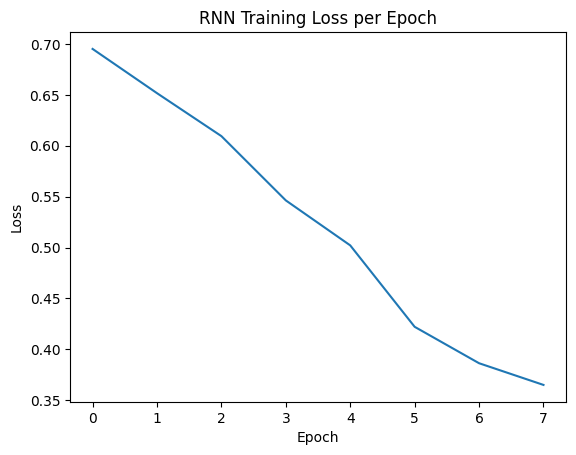

In [15]:
plt.plot(rnn_train_losses)
plt.title("RNN Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [16]:
rnn_cm = confusion_matrix(rnn_labels, rnn_preds)
print("\nConfusion Matrix:")
print(rnn_cm)


Confusion Matrix:
[[8933 3567]
 [2562 9938]]


In [17]:
print("\nRNN Report")
print(classification_report(rnn_labels, rnn_preds))


RNN Report
              precision    recall  f1-score   support

           0       0.78      0.71      0.74     12500
           1       0.74      0.80      0.76     12500

    accuracy                           0.75     25000
   macro avg       0.76      0.75      0.75     25000
weighted avg       0.76      0.75      0.75     25000



In [18]:
lstm_model = LSTMClassifier(len(vocab)).to(DEVICE)

In [19]:
lstm_train_losses = train_model(lstm_model, train_loader)

Epoch 1/8 - Loss: 0.6002
Epoch 2/8 - Loss: 0.4361
Epoch 3/8 - Loss: 0.3436
Epoch 4/8 - Loss: 0.2446
Epoch 5/8 - Loss: 0.1800
Epoch 6/8 - Loss: 0.1234
Epoch 7/8 - Loss: 0.0888
Epoch 8/8 - Loss: 0.0538


In [20]:
lstm_preds, lstm_labels = evaluate_model(lstm_model, test_loader)

Test Accuracy: 83.46%


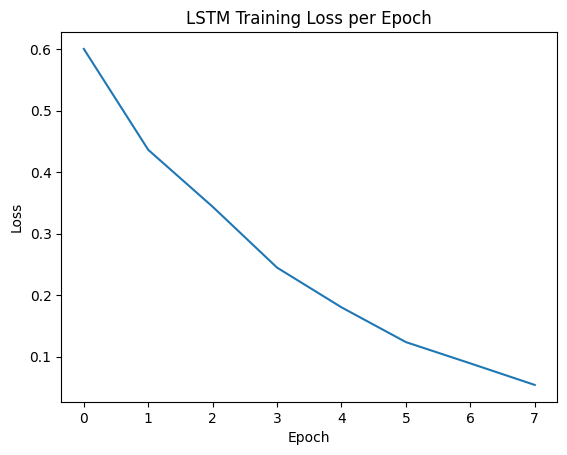

In [21]:
plt.plot(lstm_train_losses)
plt.title("LSTM Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [22]:
lstm_cm = confusion_matrix(lstm_labels, lstm_preds)
print("\nConfusion Matrix:")
print(lstm_cm)


Confusion Matrix:
[[10560  1940]
 [ 2196 10304]]


In [23]:
print("\nLSTM Report")
print(classification_report(lstm_labels, lstm_preds))


LSTM Report
              precision    recall  f1-score   support

           0       0.83      0.84      0.84     12500
           1       0.84      0.82      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000

